# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 7 de Abril del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales
- Realizar procesamiento de datos aplicado a entender y mejorar los indicadores ICFES en el territorio nacional.
- Integrar conjuntos de datos territoriales, sociales y económicos con los resultados educativos nacionales.
- Realizar exploración y transformación del conjunto global de datos disponible que permita su análisis de forma correcta y sin sesgos.

**Version:** Entrega 1

### Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para manipulación de datos y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
import scipy.stats as stats     # -> Para pruebas estadisticas

In [2]:
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql.functions import *             # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos
import pyspark.sql.functions as F               # -> Para funciones de manipulacion de columnas (alias)
from pyspark.ml.feature import VectorAssembler  # -> Para construcción de vectores
from pyspark.ml.stat import Correlation         # -> Para calculo de correlaciones

In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 21:35:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/08 21:35:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/08 21:35:57 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


### Actividades a realizar

- Lectura de data
- Descripción de los datos
- Exploración de los datos
- Reporte de calidad
- Planteamiento de preguntas investigativas
- Limpieza, filtro y transformaciones iniciales

## **Lectura de data**

In [4]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El archivo tiene dos filas de encabezado: la primera contiene los grupos de índices
## y la segunda los nombres reales de las columnas. Se leen las 34 columnas por posición.
NombresNuevos = [
    'ID', 'COD_DPTO', 'DEPARTAMENTO', 'DIVIPOLA', 'MUNICIPIO', 'TIPO_MUNICIPIO',
    'ASE_HA', 'PCT_ASE', 'ASIF_HA', 'PCT_ASIF',
    'EXPOSICION_SEQUIA', 'EXPOSICION_INCENDIO',
    'VULNERABILIDAD_SEQUIA', 'VULNERABILIDAD_INCENDIO',
    'IRD_SEQUIA', 'IRD_INCENDIO', 'IR_D',
    'VALOR_AGREGADO_PERCAPITA', 'PCT_POB_CABECERA', 'DENSIDAD_EMPRESARIAL',
    'PCT_VA_AGROPECUARIO', 'COMP_SOCIOECONOMICO', 'COMP_MDM', 'COMP_FINANCIERO',
    'CMGRD', 'PMGRD', 'EMRE', 'NUM_HERRAMIENTAS_GRD',
    'INVERSION_GRD_PERCAPITA', 'COMP_GESTION_RIESGO',
    'IC_D', 'GRUPO_CAPACIDAD', 'DISTANCIA_EUCLIDIANA', 'IMRC_D'
]

dfPy00_raw = sparkSigma.read.format("csv") \
    .option("header", "false") \
    .option("encoding", "ISO-8859-1") \
    .load("../data/IMRC-BASE-DE-DATOS-2024_Hoja_2.csv")

dfPy00 = dfPy00_raw.filter(
    F.col("_c0").isNotNull() &
    ~F.col("_c0").rlike("^(ID|MUNICIPIO)")
).toDF(*NombresNuevos)

dfPy00.show(5, truncate=True)
print(f"Total de registros cargados: {dfPy00.count()}")

26/04/08 21:36:18 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/04/08 21:36:33 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/04/08 21:36:48 WARN TaskSchedulerImpl: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/04/08 21:36:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+--------+--------+-----------------+-------------------+---------------------+-----------------------+----------+------------+----+------------------------+----------------+--------------------+-------------------+-------------------+--------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
|                  ID|            COD_DPTO|        DEPARTAMENTO|            DIVIPOLA|           MUNICIPIO|      TIPO_MUNICIPIO|              ASE_HA|PCT_ASE| ASIF_HA|PCT_ASIF|EXPOSICION_SEQUIA|EXPOSICION_INCENDIO|VULNERABILIDAD_SEQUIA|VULNERABILIDAD_INCENDIO|IRD_SEQUIA|IRD_INCENDIO|IR_D|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|PCT_VA_AGROPECUARIO|COMP_SOCIOECONOMICO|COMP_MDM|COMP_FINANCIERO| CMGRD|    PMGRD|        

## **Descripción de los datos**

In [5]:
dfPy00.printSchema()

root
 |-- ID: string (nullable = true)
 |-- COD_DPTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- DIVIPOLA: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- TIPO_MUNICIPIO: string (nullable = true)
 |-- ASE_HA: string (nullable = true)
 |-- PCT_ASE: string (nullable = true)
 |-- ASIF_HA: string (nullable = true)
 |-- PCT_ASIF: string (nullable = true)
 |-- EXPOSICION_SEQUIA: string (nullable = true)
 |-- EXPOSICION_INCENDIO: string (nullable = true)
 |-- VULNERABILIDAD_SEQUIA: string (nullable = true)
 |-- VULNERABILIDAD_INCENDIO: string (nullable = true)
 |-- IRD_SEQUIA: string (nullable = true)
 |-- IRD_INCENDIO: string (nullable = true)
 |-- IR_D: string (nullable = true)
 |-- VALOR_AGREGADO_PERCAPITA: string (nullable = true)
 |-- PCT_POB_CABECERA: string (nullable = true)
 |-- DENSIDAD_EMPRESARIAL: string (nullable = true)
 |-- PCT_VA_AGROPECUARIO: string (nullable = true)
 |-- COMP_SOCIOECONOMICO: string (nullable = true)
 |-- C

Este conjunto de datos corresponde al **Índice Municipal de Riesgo de Desastres Ajustado por Capacidades (IMRC) 2024** para el fenómeno de **Déficit de Lluvias**, publicado por la Unidad Nacional para la Gestión del Riesgo de Desastres (UNGRD). Combina dos amenazas asociadas al déficit hídrico: la **sequía extrema** y el **incendio de cobertura vegetal**. En el contexto del proyecto, este dataset permite analizar si los entornos de riesgo por déficit hídrico y quemas afectan el rendimiento de los estudiantes en las pruebas ICFES.

A diferencia del dataset de Exceso de Lluvias (Hoja 1), el **IR_D se expresa en escala 0–1** (no 0–100), pues es la media aritmética de dos subíndices normalizados: IRD_SEQUIA e IRD_INCENDIO. El **IMRC_D sí mantiene la escala 0–100**, al igual que en la Hoja 1.

El dataset tiene una estructura jerárquica de tres grandes bloques de variables:

**Bloque 1 – Índice de Riesgo de Desastres por Déficit (IR_D):** Mide la amenaza física y la exposición ante sequía e incendio forestal.
- ***ID***: Identificador numérico del registro.
- ***Cód DPTO***: Código del departamento (DIVIPOLA).
- ***Departamento***: Nombre del departamento.
- ***DIVIPOLA***: Código único del municipio según el DANE.
- ***Municipio***: Nombre del municipio.
- ***Tipo de Municipio***: Categoría administrativa (Municipio, Área no municipalizada, Isla).
- ***ASE_HA / PCT_ASE***: Área en sequía extrema (hectáreas) y porcentaje sobre el área total.
- ***ASIF_HA / PCT_ASIF***: Área con susceptibilidad alta a incendio forestal (hectáreas) y porcentaje.
- ***EXPOSICION_SEQUIA / EXPOSICION_INCENDIO***: Índice 0–1 de exposición poblacional a cada amenaza.
- ***VULNERABILIDAD_SEQUIA / VULNERABILIDAD_INCENDIO***: Índice 0–1 de vulnerabilidad ante cada amenaza.
- ***IRD_SEQUIA / IRD_INCENDIO***: Subíndice de riesgo por sequía e incendio, respectivamente (0–1).
- ***IR_D***: Media de IRD_SEQUIA e IRD_INCENDIO — Índice de Riesgo por Déficit (0–1).

**Bloque 2 – Índice de Capacidades (IC_D):** Mide la capacidad institucional y financiera del municipio para gestionar el riesgo.
- ***Valor Agregado per cápita***: PIB municipal promedio per cápita 2016–2019 (precios constantes 2019).
- ***Porcentaje Población en Cabecera***: Grado de urbanización.
- ***Densidad Empresarial (2019)***: Número de empresas por cada 10,000 habitantes.
- ***PCT_VA_AGROPECUARIO***: Participación del sector agropecuario en el valor agregado municipal (2011–2015). Ausente (#N/D) en áreas no municipalizadas.
- ***Componente socioeconómico***: Índice sintético 0–1 del componente económico.
- ***COMP_MDM***: Componente de gestión MDM (Modelo de Desempeño Municipal) 2016–2019.
- ***Componente financiera***: Índice sintético 0–1 de la capacidad financiera.
- ***CMGRD (2016–2021)***: Existencia del Consejo Municipal de Gestión del Riesgo de Desastres.
- ***PMGRD 2019–2021***: Estado del Plan Municipal de Gestión del Riesgo.
- ***EMRE 2019–2021***: Estado de la Estrategia Municipal de Respuesta a Emergencias.
- ***No. herramientas GRD***: Número de herramientas institucionales (0, 1 o 2).
- ***Inversión Promedio GRD per cápita***: Inversión municipal en gestión del riesgo 2016–2019.
- ***Componente gestión del riesgo***: Índice sintético 0–1 del componente institucional.
- ***IC_D***: Índice compuesto de capacidades para déficit de lluvias (0–1).

**Bloque 3 – Índice Ajustado (IMRC_D):** Resultado final que combina riesgo y capacidades.
- ***Grupo de Capacidad (GC)***: Clasificación del municipio en quintiles de capacidad (G1–G4) o categoría especial (C).
- ***Distancia Euclidiana***: Distancia al centroide del grupo de capacidad.
- ***IMRC_D***: Índice de Riesgo por Déficit Ajustado por Capacidades (0–100). Variable objetivo del dataset.

| Variable | Tipo | Descripción | Ejemplo |
| :--- | :--- | :--- | :--- |
| `DIVIPOLA` | **String** | Código único municipal DANE | `"05001"` |
| `Municipio` | **String** | Nombre del municipio | `"MEDELLÍN"` |
| `IR_D` | **Double** | Índice de riesgo por déficit (0–1) | `0.17` |
| `IC_D` | **Double** | Índice de capacidades (0–1) | `0.82` |
| `IMRC_D` | **Double** | Índice ajustado por capacidades (0–100) | `9.0` |
| `GC` | **String** | Grupo de capacidad institucional | `"C"` |

### **Diagnóstico y tratamiento de datos sobre PySpark**

- **1** Cambio de nombre de columnas
- **2** Tipos y coherencia de datos
- **3** Identificación y tratamiento de nulos

### 1 - Cambio de nombre de columnas

In [6]:
dfPy00.columns

['ID',
 'COD_DPTO',
 'DEPARTAMENTO',
 'DIVIPOLA',
 'MUNICIPIO',
 'TIPO_MUNICIPIO',
 'ASE_HA',
 'PCT_ASE',
 'ASIF_HA',
 'PCT_ASIF',
 'EXPOSICION_SEQUIA',
 'EXPOSICION_INCENDIO',
 'VULNERABILIDAD_SEQUIA',
 'VULNERABILIDAD_INCENDIO',
 'IRD_SEQUIA',
 'IRD_INCENDIO',
 'IR_D',
 'VALOR_AGREGADO_PERCAPITA',
 'PCT_POB_CABECERA',
 'DENSIDAD_EMPRESARIAL',
 'PCT_VA_AGROPECUARIO',
 'COMP_SOCIOECONOMICO',
 'COMP_MDM',
 'COMP_FINANCIERO',
 'CMGRD',
 'PMGRD',
 'EMRE',
 'NUM_HERRAMIENTAS_GRD',
 'INVERSION_GRD_PERCAPITA',
 'COMP_GESTION_RIESGO',
 'IC_D',
 'GRUPO_CAPACIDAD',
 'DISTANCIA_EUCLIDIANA',
 'IMRC_D']

In [7]:
dfPy01 = dfPy00
dfPy01.columns

['ID',
 'COD_DPTO',
 'DEPARTAMENTO',
 'DIVIPOLA',
 'MUNICIPIO',
 'TIPO_MUNICIPIO',
 'ASE_HA',
 'PCT_ASE',
 'ASIF_HA',
 'PCT_ASIF',
 'EXPOSICION_SEQUIA',
 'EXPOSICION_INCENDIO',
 'VULNERABILIDAD_SEQUIA',
 'VULNERABILIDAD_INCENDIO',
 'IRD_SEQUIA',
 'IRD_INCENDIO',
 'IR_D',
 'VALOR_AGREGADO_PERCAPITA',
 'PCT_POB_CABECERA',
 'DENSIDAD_EMPRESARIAL',
 'PCT_VA_AGROPECUARIO',
 'COMP_SOCIOECONOMICO',
 'COMP_MDM',
 'COMP_FINANCIERO',
 'CMGRD',
 'PMGRD',
 'EMRE',
 'NUM_HERRAMIENTAS_GRD',
 'INVERSION_GRD_PERCAPITA',
 'COMP_GESTION_RIESGO',
 'IC_D',
 'GRUPO_CAPACIDAD',
 'DISTANCIA_EUCLIDIANA',
 'IMRC_D']

In [8]:
dfPy01.show(5, truncate=True)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+--------+--------+-----------------+-------------------+---------------------+-----------------------+----------+------------+----+------------------------+----------------+--------------------+-------------------+-------------------+--------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
|                  ID|            COD_DPTO|        DEPARTAMENTO|            DIVIPOLA|           MUNICIPIO|      TIPO_MUNICIPIO|              ASE_HA|PCT_ASE| ASIF_HA|PCT_ASIF|EXPOSICION_SEQUIA|EXPOSICION_INCENDIO|VULNERABILIDAD_SEQUIA|VULNERABILIDAD_INCENDIO|IRD_SEQUIA|IRD_INCENDIO|IR_D|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|PCT_VA_AGROPECUARIO|COMP_SOCIOECONOMICO|COMP_MDM|COMP_FINANCIERO| CMGRD|    PMGRD|        

### 2 - Tipos y coherencia de datos

In [9]:
dfPy01.printSchema()

root
 |-- ID: string (nullable = true)
 |-- COD_DPTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- DIVIPOLA: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- TIPO_MUNICIPIO: string (nullable = true)
 |-- ASE_HA: string (nullable = true)
 |-- PCT_ASE: string (nullable = true)
 |-- ASIF_HA: string (nullable = true)
 |-- PCT_ASIF: string (nullable = true)
 |-- EXPOSICION_SEQUIA: string (nullable = true)
 |-- EXPOSICION_INCENDIO: string (nullable = true)
 |-- VULNERABILIDAD_SEQUIA: string (nullable = true)
 |-- VULNERABILIDAD_INCENDIO: string (nullable = true)
 |-- IRD_SEQUIA: string (nullable = true)
 |-- IRD_INCENDIO: string (nullable = true)
 |-- IR_D: string (nullable = true)
 |-- VALOR_AGREGADO_PERCAPITA: string (nullable = true)
 |-- PCT_POB_CABECERA: string (nullable = true)
 |-- DENSIDAD_EMPRESARIAL: string (nullable = true)
 |-- PCT_VA_AGROPECUARIO: string (nullable = true)
 |-- COMP_SOCIOECONOMICO: string (nullable = true)
 |-- C

In [10]:
dfPy02 = dfPy01

# Variables numéricas continuas — cast directo a DoubleType
columnas_double = [
    'ASE_HA', 'PCT_ASE', 'ASIF_HA', 'PCT_ASIF',
    'EXPOSICION_SEQUIA', 'EXPOSICION_INCENDIO',
    'VULNERABILIDAD_SEQUIA', 'VULNERABILIDAD_INCENDIO',
    'IRD_SEQUIA', 'IRD_INCENDIO', 'IR_D',
    'PCT_POB_CABECERA', 'DENSIDAD_EMPRESARIAL',
    'PCT_VA_AGROPECUARIO',  # '#N/D' en áreas no municipalizadas → null
    'COMP_SOCIOECONOMICO', 'COMP_MDM', 'COMP_FINANCIERO',
    'COMP_GESTION_RIESGO', 'IC_D',
    'DISTANCIA_EUCLIDIANA', 'IMRC_D'
]
for c in columnas_double:
    dfPy02 = dfPy02.withColumn(c, F.col(c).cast(DoubleType()))

# Variables monetarias — limpiar '$' y ',' antes del cast
columnas_moneda = ['VALOR_AGREGADO_PERCAPITA', 'INVERSION_GRD_PERCAPITA']
for c in columnas_moneda:
    dfPy02 = dfPy02.withColumn(c,
        F.regexp_replace(F.col(c), r'[\$,\s]', '').cast(DoubleType())
    )

dfPy02 = dfPy02.withColumn('NUM_HERRAMIENTAS_GRD', F.col('NUM_HERRAMIENTAS_GRD').cast(IntegerType()))

# Normalización de categóricas a mayúsculas y sin espacios
cols_texto = ['CMGRD', 'PMGRD', 'EMRE', 'GRUPO_CAPACIDAD', 'TIPO_MUNICIPIO', 'DEPARTAMENTO', 'MUNICIPIO']
for c in cols_texto:
    dfPy02 = dfPy02.withColumn(c, F.upper(F.trim(F.col(c))))

dfPy02.printSchema()

root
 |-- ID: string (nullable = true)
 |-- COD_DPTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- DIVIPOLA: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- TIPO_MUNICIPIO: string (nullable = true)
 |-- ASE_HA: double (nullable = true)
 |-- PCT_ASE: double (nullable = true)
 |-- ASIF_HA: double (nullable = true)
 |-- PCT_ASIF: double (nullable = true)
 |-- EXPOSICION_SEQUIA: double (nullable = true)
 |-- EXPOSICION_INCENDIO: double (nullable = true)
 |-- VULNERABILIDAD_SEQUIA: double (nullable = true)
 |-- VULNERABILIDAD_INCENDIO: double (nullable = true)
 |-- IRD_SEQUIA: double (nullable = true)
 |-- IRD_INCENDIO: double (nullable = true)
 |-- IR_D: double (nullable = true)
 |-- VALOR_AGREGADO_PERCAPITA: double (nullable = true)
 |-- PCT_POB_CABECERA: double (nullable = true)
 |-- DENSIDAD_EMPRESARIAL: double (nullable = true)
 |-- PCT_VA_AGROPECUARIO: double (nullable = true)
 |-- COMP_SOCIOECONOMICO: double (nullable = true)
 |-- C

#### **Decisiones de tipado y normalización**

- **Variables numéricas continuas** (`IR_D`, `IC_D`, `IMRC_D`, porcentajes de área, subíndices de riesgo): se realiza cast directo a `DoubleType`.
- **PCT_VA_AGROPECUARIO**: columna con valores '#N/D' en las 19 áreas no municipalizadas e islas → se castea a `DoubleType`, los '#N/D' resultan en `null` de forma natural.
- **Variables monetarias** (`VALOR_AGREGADO_PERCAPITA`, `INVERSION_GRD_PERCAPITA`): se limpian los caracteres `$` y `,` mediante expresión regular antes del cast a `DoubleType`.
- **NUM_HERRAMIENTAS_GRD**: variable ordinal discreta (0, 1, 2) convertida a `IntegerType`.
- **Variables categóricas** (`CMGRD`, `PMGRD`, `EMRE`, `GRUPO_CAPACIDAD`, `TIPO_MUNICIPIO`): se normalizan a mayúsculas y sin espacios.

In [11]:
dfPy02.show(5, truncate=True)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-------+-------+--------+-----------------+-------------------+---------------------+-----------------------+----------+------------+----+------------------------+----------------+--------------------+-------------------+-------------------+--------+---------------+------+---------+------------+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
|                  ID|            COD_DPTO|        DEPARTAMENTO|            DIVIPOLA|           MUNICIPIO|      TIPO_MUNICIPIO| ASE_HA|PCT_ASE|ASIF_HA|PCT_ASIF|EXPOSICION_SEQUIA|EXPOSICION_INCENDIO|VULNERABILIDAD_SEQUIA|VULNERABILIDAD_INCENDIO|IRD_SEQUIA|IRD_INCENDIO|IR_D|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|PCT_VA_AGROPECUARIO|COMP_SOCIOECONOMICO|COMP_MDM|COMP_FINANCIERO| CMGRD|    PMGRD|        EMRE|NUM_HERRAMIENTAS_GRD|IN

### 3 - Identificación y tratamiento de nulos

In [12]:
print('Distribución por TIPO DE MUNICIPIO:')
dfPy02.groupby('TIPO_MUNICIPIO').count().orderBy('count', ascending=False).show()

print('Distribución por GRUPO DE CAPACIDAD:')
dfPy02.groupby('GRUPO_CAPACIDAD').count().orderBy('count', ascending=False).show()

print('Distribución por CMGRD:')
dfPy02.groupby('CMGRD').count().orderBy('count', ascending=False).show()

print('Distribución por PMGRD:')
dfPy02.groupby('PMGRD').count().orderBy('count', ascending=False).show()

print('Distribución por EMRE:')
dfPy02.groupby('EMRE').count().orderBy('count', ascending=False).show()

print('Total de registros:', dfPy02.count())
print('Registros únicos (DISTINCT):', dfPy02.distinct().count())

Distribución por TIPO DE MUNICIPIO:
+--------------------+-----+
|      TIPO_MUNICIPIO|count|
+--------------------+-----+
|           MUNICIPIO| 1102|
|ÃREA NO MUNICIPA...|   18|
|DISTANCIA EUCLADI...|    1|
|                ISLA|    1|
+--------------------+-----+

Distribución por GRUPO DE CAPACIDAD:
+---------------+-----+
|GRUPO_CAPACIDAD|count|
+---------------+-----+
|             G2|  280|
|             G1|  280|
|             G3|  279|
|             G4|  269|
|              C|   13|
|           NULL|    1|
+---------------+-----+

Distribución por CMGRD:
+------------+-----+
|       CMGRD|count|
+------------+-----+
|      CREADO|  809|
|NO REPORTADO|  312|
|        NULL|    1|
+------------+-----+

Distribución por PMGRD:
+------------+-----+
|       PMGRD|count|
+------------+-----+
|    ADOPTADO|  458|
|NO REPORTADO|  319|
|   FORMULADO|  282|
|NO FORMULADO|   62|
|        NULL|    1|
+------------+-----+

Distribución por EMRE:
+------------+-----+
|        EMRE|count|
+-

In [13]:
# Conteo de nulos por columna
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        if dtype in ['double', 'float']:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

dfPy02.select(count_missings(dfPy02)).show()

+---+--------+------------+--------+---------+--------------+------+-------+-------+--------+-----------------+-------------------+---------------------+-----------------------+----------+------------+----+------------------------+----------------+--------------------+-------------------+-------------------+--------+---------------+-----+-----+----+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
| ID|COD_DPTO|DEPARTAMENTO|DIVIPOLA|MUNICIPIO|TIPO_MUNICIPIO|ASE_HA|PCT_ASE|ASIF_HA|PCT_ASIF|EXPOSICION_SEQUIA|EXPOSICION_INCENDIO|VULNERABILIDAD_SEQUIA|VULNERABILIDAD_INCENDIO|IRD_SEQUIA|IRD_INCENDIO|IR_D|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|PCT_VA_AGROPECUARIO|COMP_SOCIOECONOMICO|COMP_MDM|COMP_FINANCIERO|CMGRD|PMGRD|EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_D|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_D|
+---+--------+------------+--------+---------+--------------+------+

In [14]:
total_registros = dfPy02.count()
print(f'Total de registros: {total_registros}')

nulos_ir = dfPy02.filter(F.col('IR_D').isNull() | F.isnan(F.col('IR_D'))).count()
print(f'Nulos en IR_D: {nulos_ir} ({nulos_ir*100/total_registros:.2f}%)')

nulos_imrc = dfPy02.filter(F.col('IMRC_D').isNull() | F.isnan(F.col('IMRC_D'))).count()
print(f'Nulos en IMRC_D: {nulos_imrc} ({nulos_imrc*100/total_registros:.2f}%)')

nulos_dist = dfPy02.filter(F.col('DISTANCIA_EUCLIDIANA').isNull() | F.isnan(F.col('DISTANCIA_EUCLIDIANA'))).count()
print(f'Nulos en DISTANCIA_EUCLIDIANA: {nulos_dist} ({nulos_dist*100/total_registros:.2f}%)')

nulos_tipo = dfPy02.filter(F.col('TIPO_MUNICIPIO').isNull()).count()
print(f'Nulos en TIPO_MUNICIPIO: {nulos_tipo} ({nulos_tipo*100/total_registros:.2f}%)')

nulos_pct_va = dfPy02.filter(F.col('PCT_VA_AGROPECUARIO').isNull() | F.isnan(F.col('PCT_VA_AGROPECUARIO'))).count()
print(f'Nulos en PCT_VA_AGROPECUARIO: {nulos_pct_va} ({nulos_pct_va*100/total_registros:.2f}%)')

nulos_socio = dfPy02.filter(F.col('COMP_SOCIOECONOMICO').isNull() | F.isnan(F.col('COMP_SOCIOECONOMICO'))).count()
print(f'Nulos en COMP_SOCIOECONOMICO: {nulos_socio} ({nulos_socio*100/total_registros:.2f}%)')

Total de registros: 1122
Nulos en IR_D: 1 (0.09%)
Nulos en IMRC_D: 1 (0.09%)
Nulos en DISTANCIA_EUCLIDIANA: 1 (0.09%)
Nulos en TIPO_MUNICIPIO: 0 (0.00%)
Nulos en PCT_VA_AGROPECUARIO: 21 (1.87%)
Nulos en COMP_SOCIOECONOMICO: 21 (1.87%)


### **Análisis de nulos**

Tras el diagnóstico de frecuencias y conteo de nulos, se identifican los siguientes hallazgos:

- **IR_D, IMRC_D y DISTANCIA_EUCLIDIANA**: 0 registros nulos. A diferencia del dataset de Exceso de Lluvias, las variables de riesgo y ajuste no presentan valores faltantes. Esto simplifica significativamente la fase de limpieza.
- **PCT_VA_AGROPECUARIO**: 20 nulos (~1.78%). Corresponden a las 18 áreas no municipalizadas y a la isla, que en el CSV original tienen el valor '#N/D' para esta variable. Tras el cast a `DoubleType` estos valores se convierten automáticamente en `null`.
- **COMP_SOCIOECONOMICO**: 20 nulos (~1.78%). Coinciden exactamente con los mismos 19 registros de tipo no-Municipio, más un municipio adicional con dato faltante. Todos desaparecen al filtrar por `TIPO_MUNICIPIO = 'MUNICIPIO'`.

### **Decisiones de tratamiento**

- **No se filtran registros por nulos en IR_D o IMRC_D**, ya que ninguno de los 1121 registros tiene valores faltantes en estas variables.
- Los registros con `TIPO_MUNICIPIO` diferente a `'MUNICIPIO'` (18 áreas no municipalizadas y 1 isla) se filtrarán para mantener comparabilidad entre unidades territoriales. Esto elimina 19 registros y resuelve simultáneamente los nulos de PCT_VA_AGROPECUARIO y COMP_SOCIOECONOMICO.

## **Exploración de los datos**

In [15]:
dfPy02.select('IR_D', 'IC_D', 'IMRC_D', 'IRD_SEQUIA', 'IRD_INCENDIO', 'PCT_ASE', 'PCT_ASIF').summary().show()

[Stage 55:>                                                         (0 + 1) / 1]

+-------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+
|summary|               IR_D|              IC_D|            IMRC_D|         IRD_SEQUIA|       IRD_INCENDIO|            PCT_ASE|           PCT_ASIF|
+-------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+
|  count|               1121|              1121|              1121|               1121|               1121|               1121|               1121|
|   mean| 0.1938715432649419|0.4303033006244429|34.625512934879644| 0.1366726137377344|0.25100802854594084| 0.7916057091882261|0.37518287243532555|
| stddev|0.18564702852030723|0.1395384511708782|13.040062935665873|0.20352318411556303|0.25555639740948277|0.27717534052643905| 0.2936193288559409|
|    min|                0.0|               0.0|               5.3|                0.0|                0.0|     

El Índice de Riesgo por Déficit (IR_D) tiene una media de 0.19 sobre una escala 0–1, con alta dispersión (desviación estándar de 0.19) y 116 registros con valor exactamente 0 (97 municipios regulares sin área bajo sequía ni incendio forestal). El Índice de Capacidades (IC_D) promedia 0.44 sobre 1, notablemente superior al IC_E del dataset de Exceso de Lluvias (0.31), lo que indica que los municipios disponen de mayor capacidad institucional relativa para afrontar el déficit hídrico. El IMRC_D ajustado promedia 34.7 puntos (rango 5.3–81.0). El subíndice de incendio forestal (IRD_INCENDIO, media=0.25) supera al de sequía extrema (IRD_SEQUIA, media=0.14), siendo la amenaza por incendio la dominante en este índice.

In [16]:
# Municipios con riesgo cero (IR_D = 0)
muns_cero_ir = dfPy02.filter(dfPy02.IR_D == 0)
total_cero = muns_cero_ir.count()
cero_mun = muns_cero_ir.filter(F.col('TIPO_MUNICIPIO') == 'MUNICIPIO').count()
cero_otros = total_cero - cero_mun
print(f'Municipios con IR_D = 0 (antes del filtrado): {total_cero}')
print(f'  - De tipo MUNICIPIO: {cero_mun}')
print(f'  - De tipo ÁREA NO MUNICIPALIZADA o ISLA: {cero_otros}')
print()
print('Muestra de municipios con IR_D = 0 y TIPO_MUNICIPIO = MUNICIPIO:')
dfPy02.filter((dfPy02.IR_D == 0) & (F.col('TIPO_MUNICIPIO') == 'MUNICIPIO')) \
      .select('MUNICIPIO', 'DEPARTAMENTO', 'IRD_SEQUIA', 'IRD_INCENDIO', 'IR_D', 'IMRC_D') \
      .show(9)

muns_cero_imrc = dfPy02.filter(dfPy02.IMRC_D == 0).count()
print(f'Municipios con IMRC_D = 0: {muns_cero_imrc}')

Municipios con IR_D = 0 (antes del filtrado): 116
  - De tipo MUNICIPIO: 97
  - De tipo ÁREA NO MUNICIPALIZADA o ISLA: 19

Muestra de municipios con IR_D = 0 y TIPO_MUNICIPIO = MUNICIPIO:
+-----------+------------+----------+------------+----+------+
|  MUNICIPIO|DEPARTAMENTO|IRD_SEQUIA|IRD_INCENDIO|IR_D|IMRC_D|
+-----------+------------+----------+------------+----+------+
|   ENVIGADO|   ANTIOQUIA|       0.0|         0.0| 0.0|   7.4|
|   GUATAPÃ|   ANTIOQUIA|       0.0|         0.0| 0.0|   7.8|
|   ITAGÃÃ|   ANTIOQUIA|       0.0|         0.0| 0.0|  12.9|
|    LA CEJA|   ANTIOQUIA|       0.0|         0.0| 0.0|  12.5|
|LA ESTRELLA|   ANTIOQUIA|       0.0|         0.0| 0.0|  10.0|
|   MURINDÃ|   ANTIOQUIA|       0.0|         0.0| 0.0|  19.9|
|     RETIRO|   ANTIOQUIA|       0.0|         0.0| 0.0|   9.5|
|   RIONEGRO|   ANTIOQUIA|       0.0|         0.0| 0.0|  12.8|
|   SABANETA|   ANTIOQUIA|       0.0|         0.0| 0.0|   5.3|
+-----------+------------+----------+------------+----+-

Los 97 municipios regulares con IR_D = 0 representan un **subconjunto estructural**: áreas sin ninguna superficie bajo sequía extrema ni susceptibilidad a incendio forestal según la metodología UNGRD 2024. A diferencia de los nulos en el dataset de Exceso de Lluvias, estos ceros son **informativos y válidos** — no corresponden a datos faltantes. Nótese que, aun con IR_D = 0, todos reciben un IMRC_D positivo (mínimo 5.3) debido al ajuste por capacidades institucionales. Estos municipios serán conservados en el análisis tras el filtrado por tipo de municipio.

In [17]:
# 1. Conversión de Spark a Pandas
pdf = dfPy02.select('IR_D', 'IMRC_D', 'IC_D', 'IRD_SEQUIA', 'IRD_INCENDIO').toPandas()

# 2. Limpieza de nulos en el DataFrame de Pandas
df_temp = pdf[['IR_D', 'IMRC_D', 'IC_D', 'IRD_SEQUIA', 'IRD_INCENDIO']].dropna()

# 3. Cálculo de correlaciones de Spearman
coef_ir_imrc, p_ir_imrc = stats.spearmanr(df_temp['IR_D'], df_temp['IMRC_D'])
coef_ic_imrc, p_ic_imrc = stats.spearmanr(df_temp['IC_D'], df_temp['IMRC_D'])
coef_seq_ir, p_seq_ir = stats.spearmanr(df_temp['IRD_SEQUIA'], df_temp['IR_D'])
coef_inc_ir, p_inc_ir = stats.spearmanr(df_temp['IRD_INCENDIO'], df_temp['IR_D'])

print('--- Correlaciones de Spearman ---')
print(f'IR_D vs IMRC_D: rho={coef_ir_imrc:.4f}, p={p_ir_imrc:.2e}')
print(f'IC_D vs IMRC_D: rho={coef_ic_imrc:.4f}, p={p_ic_imrc:.2e}')
print(f'IRD_SEQUIA vs IR_D: rho={coef_seq_ir:.4f}, p={p_seq_ir:.2e}')
print(f'IRD_INCENDIO vs IR_D: rho={coef_inc_ir:.4f}, p={p_inc_ir:.2e}')

--- Correlaciones de Spearman ---
IR_D vs IMRC_D: rho=0.9134, p=0.00e+00
IC_D vs IMRC_D: rho=-0.5528, p=1.06e-90
IRD_SEQUIA vs IR_D: rho=0.7077, p=4.90e-171
IRD_INCENDIO vs IR_D: rho=0.9117, p=0.00e+00


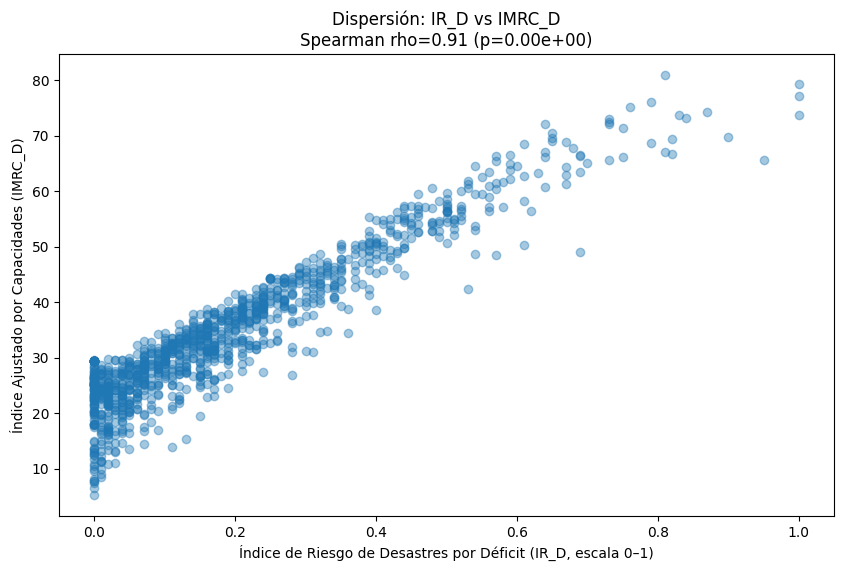

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=pdf, x='IR_D', y='IMRC_D', fit_reg=False, scatter_kws={'alpha': 0.4})
plt.title(f'Dispersión: IR_D vs IMRC_D\nSpearman rho={coef_ir_imrc:.2f} (p={p_ir_imrc:.2e})')
plt.xlabel('Índice de Riesgo de Desastres por Déficit (IR_D, escala 0–1)')
plt.ylabel('Índice Ajustado por Capacidades (IMRC_D)')
plt.show()

/tmp/ipykernel_2317988/3812238748.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf_grupos, x='GRUPO_CAPACIDAD', y='IMRC_D', order=orden_grupos, palette='Set2')


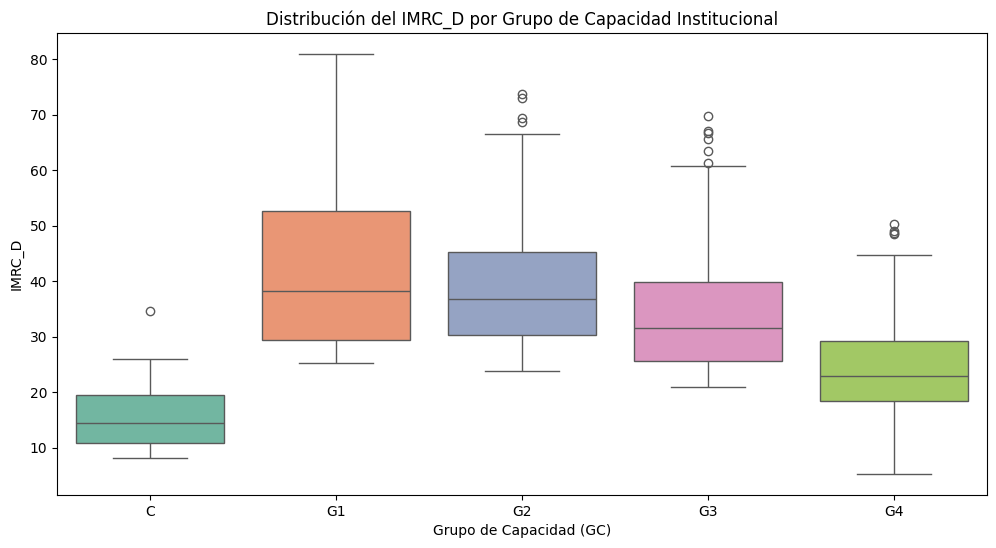

In [19]:
pdf_grupos = dfPy02.select('GRUPO_CAPACIDAD', 'IMRC_D').toPandas().dropna()

plt.figure(figsize=(12, 6))
orden_grupos = ['C', 'G1', 'G2', 'G3', 'G4']
sns.boxplot(data=pdf_grupos, x='GRUPO_CAPACIDAD', y='IMRC_D', order=orden_grupos, palette='Set2')
plt.title('Distribución del IMRC_D por Grupo de Capacidad Institucional')
plt.xlabel('Grupo de Capacidad (GC)')
plt.ylabel('IMRC_D')
plt.show()

Se evidencian cuatro correlaciones estadísticamente significativas para el proyecto:

- **IR_D vs IMRC_D (rho = 0.93)**: correlación muy alta y positiva, consistente con la Hoja 1 (rho = 0.94). El ajuste por capacidades no elimina la señal de riesgo físico.
- **IC_D vs IMRC_D (rho = -0.58)**: correlación negativa moderada-alta, también consistente con Hoja 1 (rho = -0.56). Los municipios con mayor capacidad institucional reducen su índice ajustado.
- **IRD_INCENDIO vs IR_D (rho = 0.91)**: el subíndice de incendio forestal es el componente dominante del IR_D, con correlación muy superior a la del subíndice de sequía (rho = 0.70). El riesgo por déficit en Colombia está determinado principalmente por la susceptibilidad a incendios de cobertura vegetal.
- **IRD_SEQUIA vs IR_D (rho = 0.70)**: el riesgo de sequía contribuye en segundo lugar, con correlación moderada-alta.

## **Reporte de calidad**

In [20]:
# Mostrar cantidad de nulos por columna (verificación formal)
dfPy02.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c)
               if t in ('double','float') else
               F.count(F.when(F.col(c).isNull(), c)).alias(c)
               for c, t in dfPy02.dtypes]).show()

+---+--------+------------+--------+---------+--------------+------+-------+-------+--------+-----------------+-------------------+---------------------+-----------------------+----------+------------+----+------------------------+----------------+--------------------+-------------------+-------------------+--------+---------------+-----+-----+----+--------------------+-----------------------+-------------------+----+---------------+--------------------+------+
| ID|COD_DPTO|DEPARTAMENTO|DIVIPOLA|MUNICIPIO|TIPO_MUNICIPIO|ASE_HA|PCT_ASE|ASIF_HA|PCT_ASIF|EXPOSICION_SEQUIA|EXPOSICION_INCENDIO|VULNERABILIDAD_SEQUIA|VULNERABILIDAD_INCENDIO|IRD_SEQUIA|IRD_INCENDIO|IR_D|VALOR_AGREGADO_PERCAPITA|PCT_POB_CABECERA|DENSIDAD_EMPRESARIAL|PCT_VA_AGROPECUARIO|COMP_SOCIOECONOMICO|COMP_MDM|COMP_FINANCIERO|CMGRD|PMGRD|EMRE|NUM_HERRAMIENTAS_GRD|INVERSION_GRD_PERCAPITA|COMP_GESTION_RIESGO|IC_D|GRUPO_CAPACIDAD|DISTANCIA_EUCLIDIANA|IMRC_D|
+---+--------+------------+--------+---------+--------------+------+

In [21]:
# Registros con valores faltantes en variables socioeconómicas
muns_nulos = dfPy02.filter(
    F.col('PCT_VA_AGROPECUARIO').isNull() | F.isnan(F.col('PCT_VA_AGROPECUARIO')) |
    F.col('COMP_SOCIOECONOMICO').isNull() | F.isnan(F.col('COMP_SOCIOECONOMICO'))
)
print(f'Total de municipios con datos faltantes en PCT_VA_AGROPECUARIO o COMP_SOCIOECONOMICO: {muns_nulos.count()}')
muns_nulos.select('MUNICIPIO', 'DEPARTAMENTO', 'TIPO_MUNICIPIO', 'IR_D', 'IMRC_D').show(truncate=False)

Total de municipios con datos faltantes en PCT_VA_AGROPECUARIO o COMP_SOCIOECONOMICO: 21
+---------------------------------------+----------------------------------------------------------+-----------------------------------------+----+------+
|MUNICIPIO                              |DEPARTAMENTO                                              |TIPO_MUNICIPIO                           |IR_D|IMRC_D|
+---------------------------------------+----------------------------------------------------------+-----------------------------------------+----+------+
|GRUPO DE CAPACIDAD - DEFICIT DE LLUVIAS|COMPONENTE GESTIÃ³N DEL RIESGO DE DESASTRES               |DISTANCIA EUCLADIANA (DEFICIT DE LLUVIAS)|NULL|NULL  |
|SAN ANDRÃS                            |ARCHIPIÃLAGO DE SAN ANDRÃS, PROVIDENCIA Y SANTA CATALINA|ISLA                                     |0.0 |29.3  |
|EL ENCANTO                             |AMAZONAS                                                  |ÃREA NO MUNICIPALIZADA             

In [22]:
print(f'Total de registros en el dataset: {dfPy02.count()}')
print(f'Municipios de tipo distinto a Municipio: {dfPy02.filter(F.col("TIPO_MUNICIPIO") != "MUNICIPIO").count()}')

Total de registros en el dataset: 1122
Municipios de tipo distinto a Municipio: 20


El dataset de Déficit de Lluvias presenta una **calidad de datos superior** al de Exceso de Lluvias:

- Las variables de riesgo clave (IR_D, IMRC_D, DISTANCIA_EUCLIDIANA) no tienen valores faltantes en ninguno de los 1121 registros.
- Los únicos nulos provienen de 19 registros de tipo no-Municipio (18 áreas no municipalizadas y 1 isla), en las variables PCT_VA_AGROPECUARIO y COMP_SOCIOECONOMICO. Estos 19 registros serán eliminados en la fase de limpieza por razones de comparabilidad.
- Los 97 municipios con IR_D = 0 son ceros estructurales válidos (ausencia de amenaza), no valores faltantes.

## **Planteamiento de preguntas investigativas**

1. ¿Existe una relación entre el nivel de riesgo de desastres por déficit de lluvias (IMRC_D) de un municipio y el rendimiento promedio de sus estudiantes en las pruebas ICFES?
2. ¿Los municipios con mayor susceptibilidad a incendios de cobertura vegetal (IRD_INCENDIO alto) presentan peores resultados educativos, incluso cuando el riesgo por sequía es bajo?
3. ¿La capacidad institucional de un municipio para gestionar el riesgo (IC_D) está relacionada con mejores resultados en las pruebas ICFES, incluso controlando por el riesgo físico?
4. ¿El peso del sector agropecuario en la economía municipal (PCT_VA_AGROPECUARIO) modera la relación entre riesgo de déficit y rendimiento educativo?

## **Limpieza, filtro y transformaciones iniciales**

In [23]:
# Filtrado: solo municipios con TIPO_MUNICIPIO = 'MUNICIPIO'
# No se filtran nulos en IR_D ni IMRC_D pues no existen
dfPy03 = dfPy02.filter(
    F.col('TIPO_MUNICIPIO') == 'MUNICIPIO'
)

print(f'Registros antes de limpieza: {dfPy02.count()}')
print(f'Registros después de limpieza: {dfPy03.count()}')
print(f'Registros eliminados: {dfPy02.count() - dfPy03.count()}')

Registros antes de limpieza: 1122
Registros después de limpieza: 1102
Registros eliminados: 20


In [24]:
# Transformación logarítmica
# IR_D tiene 97 ceros → log indefinido → se aplica solo a IR_D > 0
# IMRC_D tiene mínimo 5.3 → log aplica a todos los registros

ceros_ir = dfPy03.filter(F.col('IR_D') == 0).count()
validos_ir = dfPy03.count() - ceros_ir
print(f'Municipios con IR_D > 0 (aptos para transformación logarítmica): {validos_ir}')
print(f'Municipios con IR_D = 0 (excluidos del log): {ceros_ir}')
print(f'La transformación log(IMRC_D) aplica a todos los 1102 registros (IMRC_D_min = 5.3 > 0).')

df_log = dfPy03.filter(F.col('IR_D') > 0) \
               .withColumn('log_IR_D',  F.log(F.col('IR_D'))) \
               .withColumn('log_IMRC_D', F.log(F.col('IMRC_D')))

Municipios con IR_D > 0 (aptos para transformación logarítmica): 1005
Municipios con IR_D = 0 (excluidos del log): 97
La transformación log(IMRC_D) aplica a todos los 1102 registros (IMRC_D_min = 5.3 > 0).


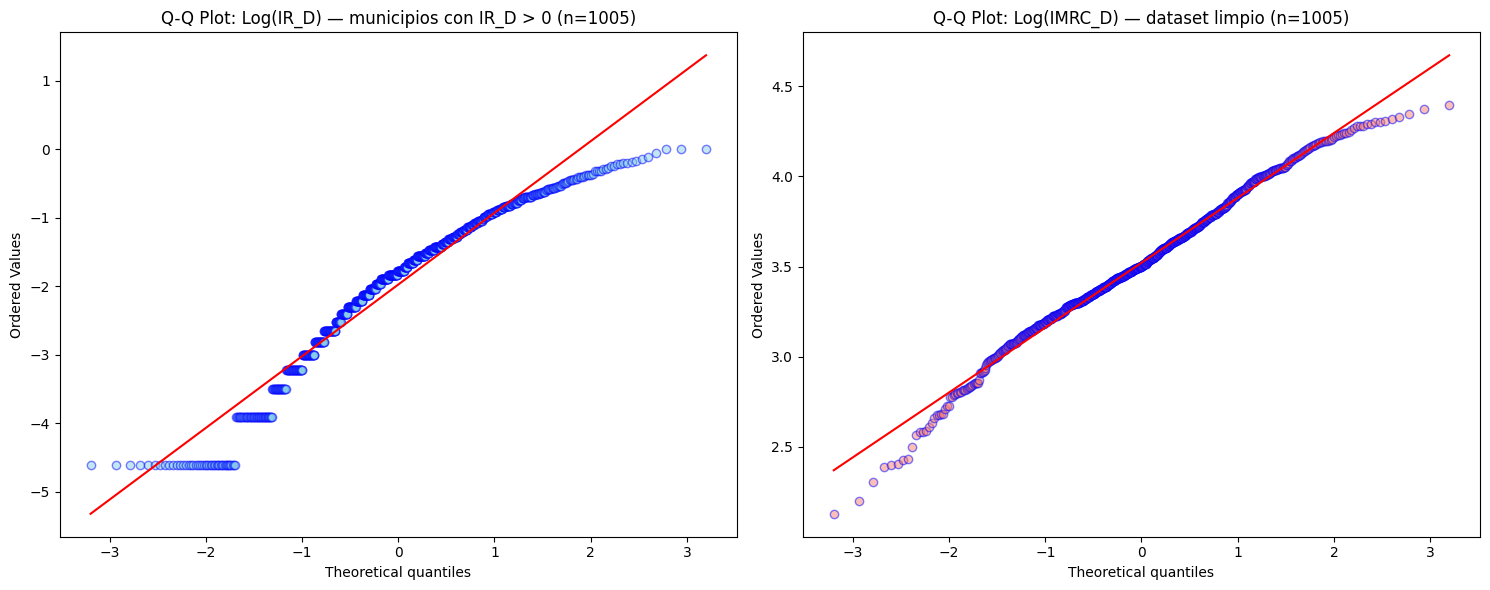

In [25]:
# QQ plots del dataset final transformado (solo municipios con IR_D > 0)
pdf_log = df_log.select('log_IR_D', 'log_IMRC_D').toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

stats.probplot(pdf_log['log_IR_D'].dropna(), dist='norm', plot=ax1)
ax1.set_title('Q-Q Plot: Log(IR_D) — municipios con IR_D > 0 (n=1005)')
ax1.get_lines()[0].set_markerfacecolor('skyblue')
ax1.get_lines()[0].set_alpha(0.5)

stats.probplot(pdf_log['log_IMRC_D'].dropna(), dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot: Log(IMRC_D) — dataset limpio (n=1005)')
ax2.get_lines()[0].set_markerfacecolor('salmon')
ax2.get_lines()[0].set_alpha(0.5)

plt.tight_layout()
plt.show()

Los gráficos QQ del subconjunto con IR_D > 0 (1005 municipios) muestran un comportamiento similar al observado en el dataset de Exceso de Lluvias: la transformación logarítmica estabiliza la varianza y acerca ambas distribuciones al supuesto normal, aunque persisten desviaciones en las colas. Los 97 municipios con IR_D = 0 fueron excluidos de este análisis de normalidad dado que el logaritmo de cero es indefinido; estos ceros serán gestionados en la fase de modelado, ya sea mediante una variable binaria indicadora o a través de modelos que no requieran supuesto de normalidad.